--- DATA UNDERSTANDING ---
Dataset Shape       : 11142 Rows, 10 Columns
Missing Values Count: 0
Duplicate Rows Count: 0
Fraudulent Rows     : 1,142
Overall Fraud Rate  : 10.2495%

Fraud Rate by Transaction Type:
type
TRANSFER    38.525
CASH_OUT    30.893
CASH_IN      0.000
DEBIT        0.000
PAYMENT      0.000
Name: Fraud Rate (%), dtype: float64


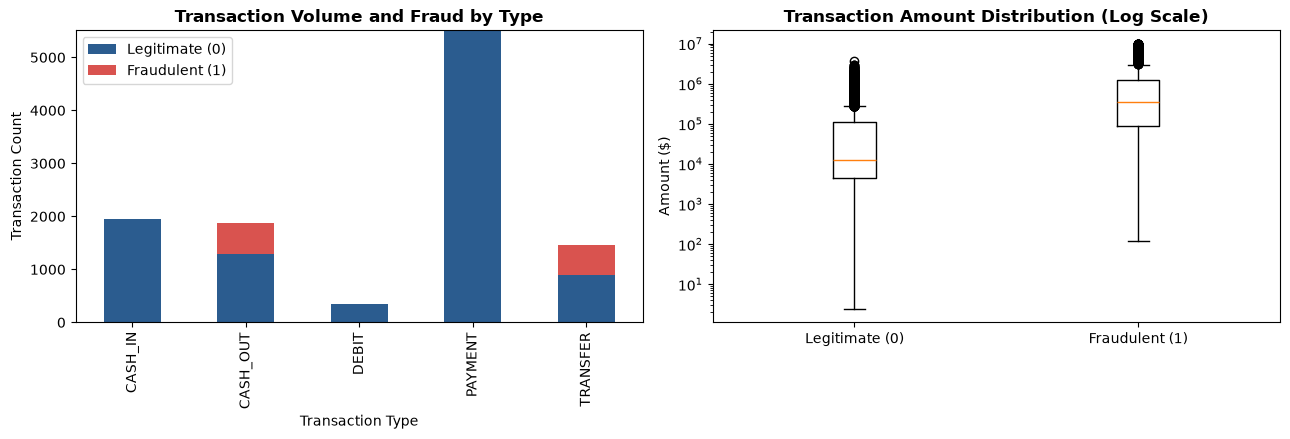

In [10]:
# Shared imports used throughout the analysis
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

# Load and inspect the dataset
df = pd.read_csv('Fraud_Analysis_Dataset.csv')

print("--- DATA UNDERSTANDING ---")
print(f"Dataset Shape       : {df.shape[0]} Rows, {df.shape[1]} Columns")
print(f"Missing Values Count: {df.isnull().sum().sum()}")
print(f"Duplicate Rows Count: {df.duplicated().sum()}")
print(f"Fraudulent Rows     : {df['isFraud'].sum():,}")
print(f"Overall Fraud Rate  : {df['isFraud'].mean():.4%}")
print("\nFraud Rate by Transaction Type:")
print((df.groupby('type')['isFraud'].mean().sort_values(ascending=False) * 100).round(3).rename('Fraud Rate (%)'))

# Plot fraud counts by transaction type
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fraud_type = df.groupby(['type', 'isFraud']).size().unstack(fill_value=0)
fraud_type.plot(kind='bar', stacked=True, ax=axes[0], color=['#2b5c8f', '#d9534f'])
axes[0].set_title('Transaction Volume and Fraud by Type', fontweight='bold')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Transaction Count')
axes[0].legend(['Legitimate (0)', 'Fraudulent (1)'])

# Compare transaction amounts on a logarithmic scale
legit_amt = df.loc[df['isFraud'] == 0, 'amount']
fraud_amt = df.loc[df['isFraud'] == 1, 'amount']
axes[1].boxplot([legit_amt, fraud_amt], tick_labels=['Legitimate (0)', 'Fraudulent (1)'])
axes[1].set_yscale('log')
axes[1].set_title('Transaction Amount Distribution (Log Scale)', fontweight='bold')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()


--- FRAUD AND AMOUNT SUMMARY BY TRANSACTION TYPE ---
          transactions  fraud_cases  fraud_rate  mean_legitimate_amount  \
type                                                                      
CASH_IN           1951            0        0.00               167994.82   
CASH_OUT          1871          578       30.89               164315.86   
DEBIT              346            0        0.00                 3590.69   
PAYMENT           5510            0        0.00                 7891.18   
TRANSFER          1464          564       38.52               476062.43   

          mean_fraud_amount  
type                         
CASH_IN                0.00  
CASH_OUT         1177134.71  
DEBIT                  0.00  
PAYMENT                0.00  
TRANSFER         1208507.77  


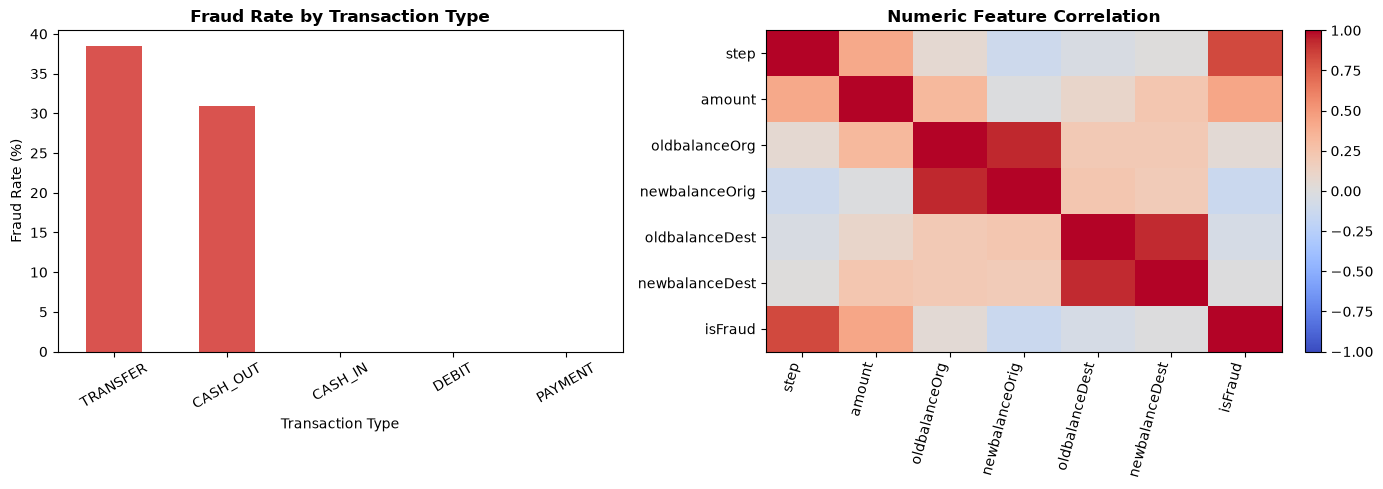

In [11]:
# Additional fraud-rate, transaction-value, and correlation analysis
fraud_by_type = df.groupby('type').agg(
    transactions=('isFraud', 'size'),
    fraud_cases=('isFraud', 'sum'),
    fraud_rate=('isFraud', 'mean'),
    mean_legitimate_amount=('amount', lambda values: values[df.loc[values.index, 'isFraud'] == 0].mean()),
    mean_fraud_amount=('amount', lambda values: values[df.loc[values.index, 'isFraud'] == 1].mean()),
)
fraud_by_type['fraud_rate'] *= 100
print('--- FRAUD AND AMOUNT SUMMARY BY TRANSACTION TYPE ---')
print(fraud_by_type.round(2).fillna(0))

numeric_features = df.select_dtypes(include=np.number).drop(columns=['isFraud'], errors='ignore')
correlation = numeric_features.join(df['isFraud']).corr(numeric_only=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fraud_by_type['fraud_rate'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='#d9534f'
)
axes[0].set_title('Fraud Rate by Transaction Type', fontweight='bold')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

image = axes[1].imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(range(len(correlation.columns)), correlation.columns, rotation=75, ha='right')
axes[1].set_yticks(range(len(correlation.index)), correlation.index)
axes[1].set_title('Numeric Feature Correlation', fontweight='bold')
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [12]:
# Prepare model features and create a stratified train-test split
# Receiver balances are only available to the app for PAYMENT and TRANSFER.
df_clean = df.drop(columns=['nameOrig', 'nameDest', 'step']).copy()
receiver_types = ['PAYMENT', 'TRANSFER']
has_receiver_balance = df_clean['type'].isin(receiver_types)
df_clean.loc[~has_receiver_balance, ['oldbalanceDest', 'newbalanceDest']] = 0.0
df_clean['errorBalanceOrig'] = (
    df_clean['newbalanceOrig'] + df_clean['amount'] - df_clean['oldbalanceOrg']
)
df_clean['errorBalanceDest'] = np.where(
    has_receiver_balance,
    df_clean['oldbalanceDest'] + df_clean['amount'] - df_clean['newbalanceDest'],
    0.0,
)

X = pd.get_dummies(
    df_clean.drop(columns=['isFraud']), columns=['type'], drop_first=True
)
y = df_clean['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train-test split completed.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train count: {y_train.shape[0]}")

Train-test split completed.
X_train shape: (8913, 11)
y_train count: 8913


In [13]:
# Train Logistic Regression, Random Forest, and Gradient Boosting models.
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()
class_weight_ratio = num_neg / num_pos
sample_weights = np.where(y_train == 1, class_weight_ratio, 1.0)

print(f"Minority-class weight ratio: {class_weight_ratio:.2f}\n")

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    ),
    "Gradient Boosting (GBDT)": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        max_features='sqrt',
        random_state=42,
    ),
}

trained_models = {}
for name, model in models.items():
    if name == "Gradient Boosting (GBDT)":
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Model trained: {name}")

Minority-class weight ratio: 8.75

Model trained: Logistic Regression
Model trained: Random Forest
Model trained: Gradient Boosting (GBDT)


--- MODEL BENCHMARK COMPARISON ---
                          Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
Model                                                                      
Logistic Regression         0.9511     0.6831  0.9737    0.8029   0.9878   
Random Forest               0.9955     0.9866  0.9693    0.9779   0.9902   
Gradient Boosting (GBDT)    0.9969     1.0000  0.9693    0.9844   0.9969   

                          PR-AUC  
Model                             
Logistic Regression       0.9546  
Random Forest             0.9863  
Gradient Boosting (GBDT)  0.9876  


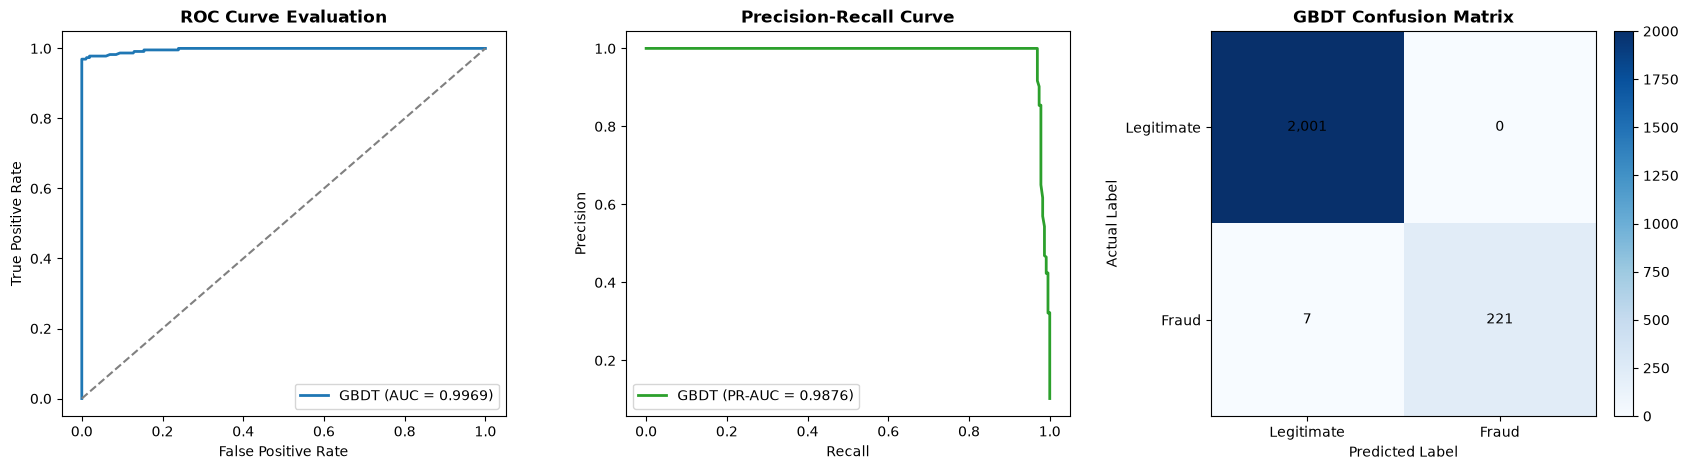

--- GBDT CLASSIFICATION REPORT (threshold = 0.45) ---
              precision    recall  f1-score   support

  Legitimate     0.9965    1.0000    0.9983      2001
       Fraud     1.0000    0.9693    0.9844       228

    accuracy                         0.9969      2229
   macro avg     0.9983    0.9846    0.9913      2229
weighted avg     0.9969    0.9969    0.9968      2229



In [14]:
# Compare accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC for each model.
# GBDT uses a 0.45 classification threshold; the other models use 0.50.
results = []
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    threshold = 0.45 if "Gradient" in name else 0.50
    y_pred = (y_proba >= threshold).astype(int)

    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "PR-AUC": pr_auc,
        }
    )

results_df = pd.DataFrame(results).set_index("Model")
print("--- MODEL BENCHMARK COMPARISON ---")
print(results_df.round(4))

# Plot ROC, precision-recall, and confusion matrix for GBDT.
best_name = "Gradient Boosting (GBDT)"
gb_proba = trained_models[best_name].predict_proba(X_test)[:, 1]
gb_pred = (gb_proba >= 0.45).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
fpr, tpr, _ = roc_curve(y_test, gb_proba)
axes[0].plot(
    fpr,
    tpr,
    color='#1f77b4',
    lw=2,
    label=f'GBDT (AUC = {roc_auc_score(y_test, gb_proba):.4f})',
)
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('ROC Curve Evaluation', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

precision_curve, recall_curve, _ = precision_recall_curve(y_test, gb_proba)
axes[1].plot(
    recall_curve,
    precision_curve,
    color='#2ca02c',
    lw=2,
    label=f'GBDT (PR-AUC = {auc(recall_curve, precision_curve):.4f})',
)
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

cm = confusion_matrix(y_test, gb_pred, labels=[0, 1])
image = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('GBDT Confusion Matrix', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('Actual Label')
axes[2].set_xticks([0, 1], ['Legitimate', 'Fraud'])
axes[2].set_yticks([0, 1], ['Legitimate', 'Fraud'])
for row in range(2):
    for column in range(2):
        axes[2].text(column, row, f'{cm[row, column]:,}', ha='center', va='center')
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("--- GBDT CLASSIFICATION REPORT (threshold = 0.45) ---")
print(classification_report(
    y_test,
    gb_pred,
    labels=[0, 1],
    target_names=['Legitimate', 'Fraud'],
    zero_division=0,
    digits=4,
))


In [15]:
# Estimate test-set financial impact and inspect GBDT feature importances.
best_model = trained_models["Gradient Boosting (GBDT)"]
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.45).astype(int)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
test_amount = df.loc[X_test.index, 'amount']
actual_fraud = y_test == 1
predicted_fraud = y_pred == 1

tp_mask = actual_fraud & predicted_fraud
fn_mask = actual_fraud & ~predicted_fraud
fp_mask = ~actual_fraud & predicted_fraud
tn_mask = ~actual_fraud & ~predicted_fraud

# Assumptions are illustrative; replace with the business's actual unit economics.
false_positive_review_cost = 15.0
assumed_fee_rate = 0.02
fraud_loss_prevented = test_amount[tp_mask].sum()
missed_fraud_loss = test_amount[fn_mask].sum()
total_test_fraud_value = test_amount[actual_fraud].sum()
legitimate_value_approved = test_amount[tn_mask].sum()
legitimate_value_held_for_review = test_amount[fp_mask].sum()
fee_revenue_retained_proxy = legitimate_value_approved * assumed_fee_rate
fee_revenue_forgone_proxy = legitimate_value_held_for_review * assumed_fee_rate
false_positive_review_cost_total = fp * false_positive_review_cost
estimated_incremental_benefit = (
    fraud_loss_prevented
    - false_positive_review_cost_total
    - fee_revenue_forgone_proxy
)

print("--- TEST-SET FINANCIAL IMPACT (ASSUMPTION-BASED) ---")
print(f"Fraud transaction value in test set       : ${total_test_fraud_value:,.2f}")
print(f"Fraud loss prevented (true-positive value): ${fraud_loss_prevented:,.2f}")
print(f"Missed fraud loss (false-negative value)  : ${missed_fraud_loss:,.2f}")
print(f"Legitimate transaction value approved     : ${legitimate_value_approved:,.2f}")
print(f"Legitimate value held for review (FP)     : ${legitimate_value_held_for_review:,.2f}")
print(f"Assumed fee rate                          : {assumed_fee_rate:.2%}")
print(f"Fee revenue retained (proxy)             : ${fee_revenue_retained_proxy:,.2f}")
print(f"Fee revenue forgone on FP (proxy)        : ${fee_revenue_forgone_proxy:,.2f}")
print(f"False-positive review cost                : ${false_positive_review_cost_total:,.2f}")
print(f"Estimated incremental benefit             : ${estimated_incremental_benefit:,.2f}")
print("Interpretation: transaction values are not company revenue. The fee rate and review cost are assumptions; actual profit needs real fees, recovery rates, and operating costs.")

print("\n--- TOP FRAUD INDICATORS ---")
feat_imp = pd.Series(
    best_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)
print(feat_imp.head(6))


--- TEST-SET FINANCIAL IMPACT (ASSUMPTION-BASED) ---
Fraud transaction value in test set       : $235,846,526.37
Fraud loss prevented (true-positive value): $232,680,742.24
Missed fraud loss (false-negative value)  : $3,165,784.13
Legitimate transaction value approved     : $205,491,066.96
Legitimate value held for review (FP)     : $0.00
Assumed fee rate                          : 2.00%
Fee revenue retained (proxy)             : $4,109,821.34
Fee revenue forgone on FP (proxy)        : $0.00
False-positive review cost                : $0.00
Estimated incremental benefit             : $232,680,742.24
Interpretation: transaction values are not company revenue. The fee rate and review cost are assumptions; actual profit needs real fees, recovery rates, and operating costs.

--- TOP FRAUD INDICATORS ---
errorBalanceOrig    0.301101
newbalanceOrig      0.233673
type_PAYMENT        0.103358
errorBalanceDest    0.095830
amount              0.072443
oldbalanceOrg       0.063415
dtype: float64


In [16]:
# Export the selected GBDT model, feature order, evaluation metrics, and version metadata.
from datetime import datetime, timezone

pipeline_artifact = {
    'artifact_version': 1,
    'model_version': '1.1.0',
    'trained_at_utc': datetime.now(timezone.utc).isoformat(),
    'model': best_model,
    'feature_columns': X_train.columns.tolist(),
    'optimal_threshold': 0.45,
    'test_metrics': results_df.loc['Gradient Boosting (GBDT)'].to_dict(),
}

joblib.dump(pipeline_artifact, 'models/final_fraud_pipeline.joblib')
print(f"Pipeline version {pipeline_artifact['model_version']} exported to 'models/final_fraud_pipeline.joblib'.")
print(f"Training timestamp (UTC): {pipeline_artifact['trained_at_utc']}")

Pipeline version 1.1.0 exported to 'models/final_fraud_pipeline.joblib'.
Training timestamp (UTC): 2026-10-01T15:06:57.175843+00:00
